# Exploratory Data Analysis
## Diarrheal Prevention Program Evaluation — Marwi Camps, Sudan 2025
**N = 116 per time point | Design: Quasi-experimental (independent pre/post samples)**

This notebook explores the pre-intervention baseline and documents the pre-post KAP shifts prior to formal comparison in SPSS.


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 12
sns.set_style("whitegrid")

pre = pd.read_excel("../1_data/cleaned/cleaned_pre.xlsx")
post = pd.read_excel("../1_data/cleaned/cleaned_post.xlsx")
n = len(pre)
print(f"Pre-intervention: {pre.shape}")
print(f"Post-intervention: {post.shape}")

Pre-intervention: (116, 69)
Post-intervention: (116, 69)


## 1. Data Quality

In [17]:
for label, df in [("Pre", pre), ("Post", post)]:
    missing = df[["knowledge_score","attitude_score","practice_score","kap_score"]].isnull().sum()
    print(f"{label}: {missing.sum()} missing values in KAP score columns")

print("\nSamples are independent (not matched).")
print(f"Pre — received prior info: {pre['prev_info'].mean()*100:.1f}%")
print(f"Post — received prior info: {post['prev_info'].mean()*100:.1f}%")

Pre: 0 missing values in KAP score columns
Post: 0 missing values in KAP score columns

Samples are independent (not matched).
Pre — received prior info: 0.9%
Post — received prior info: 100.0%


## 2. Demographic Profile (Pre-Intervention Sample)

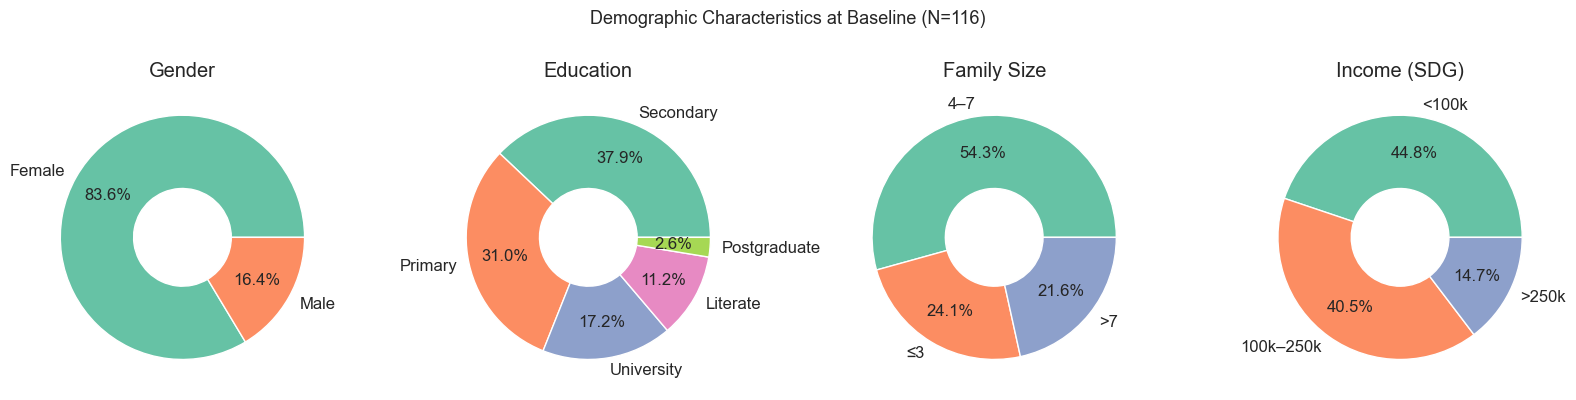

Mean age (pre): 39.2 ± 15.6 years
Mean age (post): 39.0 ± 15.3 years


In [18]:
edu_map = {1: "Literate", 2: "Primary", 3: "Secondary", 4: "University", 5: "Postgraduate"}
occ_map = {1: "Unemployed", 2: "Farmer", 3: "Trader", 4: "Teacher", 5: "Employee", 6: "Other"}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
palette = sns.color_palette("Set2")

for ax, (col, label_map, title) in zip(axes, [
    ("gender", {1: "Male", 2: "Female"}, "Gender"),
    ("edu_level", edu_map, "Education"),
    ("fam_size", {1: "≤3", 2: "4–7", 3: ">7"}, "Family Size"),
    ("income", {1: "<100k", 2: "100k–250k", 3: ">250k"}, "Income (SDG)"),
]):
    counts = pre[col].map(label_map).value_counts()
    ax.pie(counts, labels=counts.index, autopct="%1.1f%%",
           colors=palette, pctdistance=0.7, wedgeprops={"width": 0.6, "edgecolor": "white"})
    ax.set_title(title)
plt.suptitle(f"Demographic Characteristics at Baseline (N={n})", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Mean age (pre): {pre['age'].mean():.1f} ± {pre['age'].std():.1f} years")
print(f"Mean age (post): {post['age'].mean():.1f} ± {post['age'].std():.1f} years")

## 3. KAP Score Distributions at Baseline

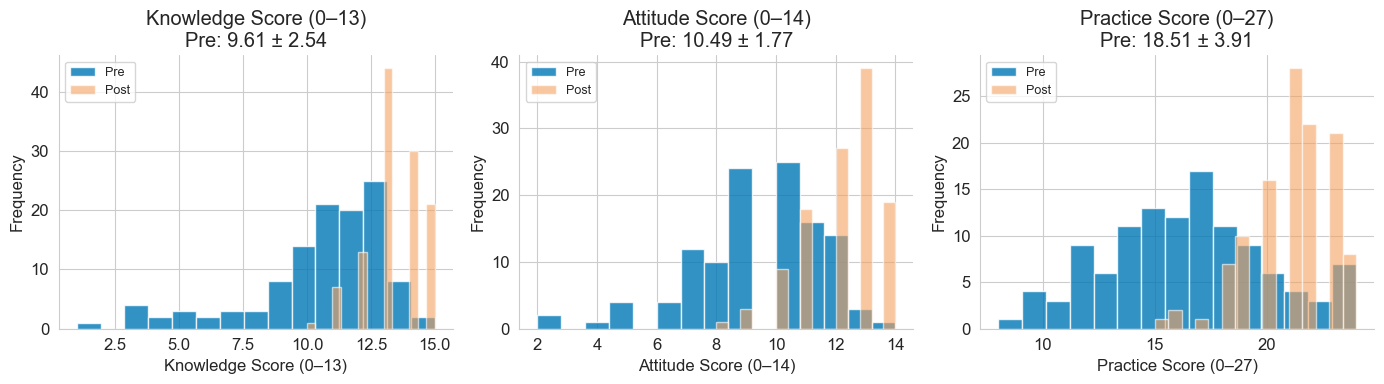

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
score_configs = [
    ("knowledge_score", "Knowledge Score (0–13)", "Pre: 9.61 ± 2.54"),
    ("attitude_score", "Attitude Score (0–14)", "Pre: 10.49 ± 1.77"),
    ("practice_score", "Practice Score (0–27)", "Pre: 18.51 ± 3.91"),
]
for ax, (col, label, note) in zip(axes, score_configs):
    ax.hist(pre[col].dropna(), bins=15, color="#0077B6", edgecolor="white", alpha=0.8, label="Pre")
    ax.hist(post[col].dropna(), bins=15, color="#F4A261", edgecolor="white", alpha=0.6, label="Post")
    ax.set_xlabel(label)
    ax.set_ylabel("Frequency")
    ax.set_title(f"{label}\n{note}")
    ax.legend(fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

## 4. Pre-Post KAP Score Comparison

In [20]:
kap_cols = [("knowledge_score", "Knowledge"), ("attitude_score", "Attitude"),
             ("practice_score", "Practice"), ("kap_score", "Composite KAP")]

print("Mean Scores Pre vs Post:")
print(f"{'Scale':<20} {'Pre Mean':>10} {'Post Mean':>10} {'Diff':>8} {'p-value':>10}")
print("-" * 60)
for col, label in kap_cols:
    pre_mean = pre[col].mean()
    post_mean = post[col].mean()
    t, p = stats.ttest_1samp(post[col].dropna(), popmean=pre_mean)
    print(f"{label:<20} {pre_mean:>10.2f} {post_mean:>10.2f} {post_mean-pre_mean:>8.2f} {p:>10.4f}")

Mean Scores Pre vs Post:
Scale                  Pre Mean  Post Mean     Diff    p-value
------------------------------------------------------------
Knowledge                 10.72      13.36     2.65     0.0000
Attitude                   9.30      12.24     2.94     0.0000
Practice                  16.36      21.09     4.73     0.0000
Composite KAP             68.68      88.14    19.46     0.0000


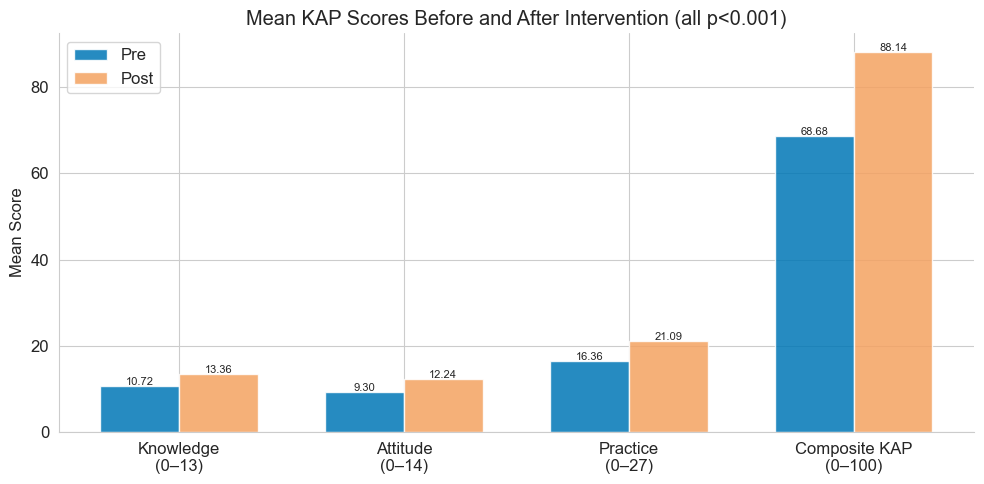

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
labels = ["Knowledge\n(0–13)", "Attitude\n(0–14)", "Practice\n(0–27)", "Composite KAP\n(0–100)"]
cols = ["knowledge_score", "attitude_score", "practice_score", "kap_score"]
pre_means = [pre[c].mean() for c in cols]
post_means = [post[c].mean() for c in cols]

x = range(len(labels))
width = 0.35
bars_pre = ax.bar([i - width/2 for i in x], pre_means, width, label="Pre", color="#0077B6", alpha=0.85)
bars_post = ax.bar([i + width/2 for i in x], post_means, width, label="Post", color="#F4A261", alpha=0.85)
for bar in list(bars_pre) + list(bars_post):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.2, f"{h:.2f}", ha="center", fontsize=8)
ax.set_xticks(list(x))
ax.set_xticklabels(labels)
ax.set_ylabel("Mean Score")
ax.set_title("Mean KAP Scores Before and After Intervention (all p<0.001)")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

## 5. Correlations Between KAP Components (Pre-Intervention)

In [22]:
kap_score_cols = ["knowledge_score", "attitude_score", "practice_score", "kap_score"]
kap_labels = ["Knowledge", "Attitude", "Practice", "Composite KAP"]

print("Spearman Correlations (Pre-Intervention):")
pairs = [
    ("knowledge_score", "attitude_score"),
    ("knowledge_score", "practice_score"),
    ("attitude_score", "practice_score"),
]
for a, b in pairs:
    r, p = stats.spearmanr(pre[a].dropna(), pre.loc[pre[a].notna() & pre[b].notna(), b])
    print(f"  {a} ↔ {b}: ρ={r:.3f}, p={p:.4f}")

Spearman Correlations (Pre-Intervention):
  knowledge_score ↔ attitude_score: ρ=0.426, p=0.0000
  knowledge_score ↔ practice_score: ρ=0.401, p=0.0000
  attitude_score ↔ practice_score: ρ=0.281, p=0.0023


## Summary of EDA Findings

| Finding | Value |
|---------|-------|
| Sample size per time point | N = 116 |
| Mean age (pre/post) | 39.16 / 38.99 years |
| Female | 83.6% / 81.9% |
| Prior intervention information (pre) | 0.9% |
| Prior intervention information (post) | 100.0% |
| Pre knowledge score (mean ± SD) | 9.61 ± 2.54 |
| Post knowledge score (mean ± SD) | 11.41 ± 1.13 |
| Pre attitude score | 10.49 ± 1.77 |
| Post attitude score | 12.58 ± 1.15 |
| Pre practice score | 18.51 ± 3.91 |
| Post practice score | 23.84 ± 2.11 |
| Pre composite KAP | 72.48 ± 11.92 |
| Post composite KAP | 88.65 ± 5.43 |
| Knowledge–Attitude correlation (ρ) | 0.282 (p=0.002) |
| Knowledge–Practice correlation (ρ) | 0.400 (p<0.001) |
| Household diarrhoea prevalence | 42.2% → 33.6% (−8.6 pp) |
| Significant baseline predictor | Education only (β=6.00, p<0.001) |

Formal one-sample t-tests and regression analyses conducted in SPSS (see `4_analysis/pre_analysis.sps`, `4_analysis/post_analysis.sps`).
